<center><h1>Image Processing</h1></center>

1. Introduction
2. Digital Image Fundamentals

## 1. Introduction

Interest in Digital Image Processing methods stems from two principal application areas:
- improvement of pictorial information for human interpretation
- processing of image data for tasks such as storage, transmission, and extraction of pictorial information

#### 1.1 Digital Image Processing

An image may be defined as a two-dimensional function, $f(x, y)$, where $x$ and $y$ are spatial coordinates, and the amplitude of $f$ at any pair of coordinates $(x, y)$ is called the intensity or gray level of the image at that point. A digital image is composed of a finite number of elements, each of which has a particular location and value. These elements are called *pixels*.

#### 1.2 Fundamental Steps in Digital Image Processing
It is helpful to divide steps in Image Processing into two categories:
1. Methods whose input and output are images
    - Image Acquisition
    - Image Filtering and Enhancement
    - Image Restoration
    - Wavelets and other image transforms
    - Compression and watermarking
    - Morphological Operations
2. Methods whose inputs may be images, but whose outputs are attibutes extracted from images
    - Segmentation
    - Feature extraction
    - Image Pattern Classification

## 2. Digital Image Fundamentals

### 2.1 Image Formation Model

An image is denoted by a 2-dimensional function $f(x,y)$. This function is characterized by two components:
1. $i(x,y)$: Amount of source illumination incident on the scene being viewed (*illumination*), and
2. $r(x,y)$: Amount of illumination reflected by objects in the scene (*reflectance*)

These two components combine to form $f(x,y)$:

$\boxed{f(x,y) = i(x,y)r(x,y)}$ **(Eq 2-1)**

where $0 \le i(x,y) < \infty$ and $0 \le r(x,y) \le 1$ **(Eq 2-2)**

Let the intensity (gray level) of a monochrome image at any coordinates $(x,y)$ be

$\boxed{l = f(x,y)}$ **(Eq 2-3)**

From equation (2-2) it is evident that $l$ lies in the range

$\boxed{L_{min} \le l \le L_{max}}$ **(Eq 2-4)**

The interval $[L_{min}, L_{max}]$ is called the intensity scale.

### 2.2 Image Sampling and Quantization

Our objective is to generate digital images from sensed data. The output of most sensors is a continuous voltage waveform whose amplitude and spatial behaviour are related to the physical phenomenon being sensed. To create a digital image, we need to convert the continuous sensed data into a digital format. This is done by two processes: sampling and quantization

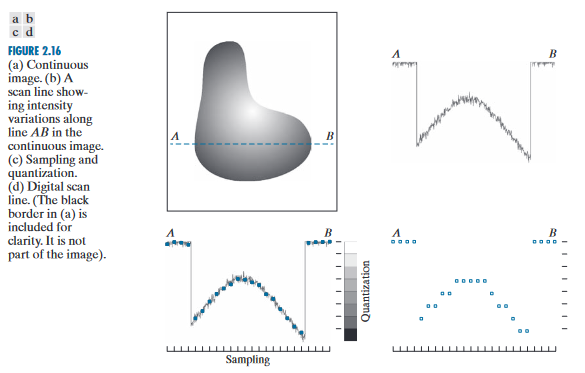

The above image (Source: DIP Gonzalez and Woods 4e) is what we want to convert to digital form. An image may be continuous with respect to the x and y-coordinates, and also in amplitude. To digitize it, we have to sample the function in both coordinates and also in amplitude. *Digitizing the coordinate values is called sampling. Digitizing the amplitude values is called quantization.*

### 2.3 Representing Digital Images

Let $f(s, t)$ represent a continuous image function of two continuous variables, $s$ and $t$. We convert this function into digital image using sampling and quantization. Suppose that we sample the continuous image into a digital image $f(x, y)$, containing $M$ rows and $N$ columns, where $(x, y)$ are discrete coordinates. We define the origin of an image at the top left corner. 

The center of an $M x N$ image with origin at (0,0) and range $(M-1, N-1)$ is obtained by dividing $M$ and $N$ by 2 and rounding down to the nearest integer. 

In [2]:
import math

M = 1023
N = 1024

center_M = math.floor(M/2)
center_N = math.floor(N/2)

print(f'Center: ({center_M}, {center_N})')

Center: (511, 512)


**Formal Definition of Sampling and Quantization**

Let $Z$ and $R$ denote set of integers and set of real numbers, respectively. The sampling process may be viewed as partitioning the $xy$-plane into a grid, with the coordinates of the center of each cell in the grid being a pair of elements from the Cartesian product $Z^{2}$. Hence, $f(x, y)$ is a digital image if $(x, y)$ are integers from $Z^{2}$ and $f$ is a function that assigns an intensity value (a real number from the set of real numbers $R$) to each distinct pair of coordinates. 

Image digitization requires that decisions be made regarding the values of $M, N$ and for the number, $L$, of discrete intensity levels. There are no restrictions on $M$ and $N$, other that they have to be positive integers. However, digital storage and quantizing hardware considerations usually lead to the number of intensity levels, being an integer power of two; that is 

$L = 2^{k}$ **(Eq 2-5)**

where $k$ is an integer. 

The range of values spanned by the gray scale is referred to as *dynamic range*. Dynamic range of an imaging system is the **ratio of maximum measurable intensity to the minimum detectable intensity level in the system.**

The number $b$, of bits required to store a digital image is 

$b = M \times N \times k$ **(Eq 2-6)**

### **2.4 Spatial and Intensity Resolution**
*Spatial resolution* is a measure of the smallest discernible detail in an image. Quantitatively, it can be stated as *line pairs per unit distance*, *dots per unit distance*, etc.

*Intensity resolution* refers to the smallest discernible change in the intensity level. Based on hardware considerations, the number of intensity levels is an integer power of two. Most common number is 8 bits, 16 bits. 

### **2.5 Image Interpolation**
Interpolation is used in tasks such as zooming, shrinking, rotating, and geometrically correcting digital images. Interpolation is the process of using known data to estimate values at unknown locations. 

- **Near Neighbor Interpolation**: Suppose that we have an image of size 500x500 pixel which has to be enlarged 1.5 times to 750x750 pixels. A simple way to visualize zooming is to create an imaginary 750x750 grid with the same pixel spacing as the original image, then shrink it so that it exactly overlays the original image. To assign an intensity value to any point in the overlay, we look for its closest pixel in the underlaying original image and assign the intensity of that pixel to the new pixel in the 750x750 grid. When intensities have been assigned to all the points in the overlay grid, we expand it back to the specified size to obtain the resized image. This method is simple but it has the tendency to produce undersirable artifacts, such as severe distortion of straight edges.

- **Bilinear Interpolation**: In this method, we use the four nearest neighbors to estimate the intensity of the given location. Let $(x,y)$ denote the coordinates of the location to which we want to assign an intensity value, and let $v(x,y)$ denote that intensity value. This intensity value is obtained using the equation $v(x, y) = ax + by + cxy + d$ where the four coefficients are determined from the four equations in four unknowns that can be written using the four nearest neighbors of point $(x, y)$

- **Bicubic Interpolation**: Bicubic interpolation involves sixteen nearest neighbors of a point. The equation of the intensity value assigned to point $(x, y)$ is given by $v(x, y) = \sum_{i=0}^{3} \sum_{j=0}^{3} a_{ij}x^iy^j$

An important illustration of interpolation is given here: https://x-engineer.org/bilinear-interpolation/

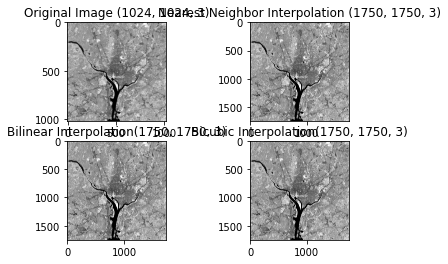

In [13]:
# interpolation
import cv2
import matplotlib.pyplot as plt

#input image
image = cv2.imread('images\map.tif')

# nearest neighbor interpolation
'''
Here, after resizing the image, we get a numpy array. To display the numpy array as an image, we
can either use the pillow library to convert it from array to image or we can save it in an image 
format like JPEG and then use the imshow() function in OpenCV. 

In case of plotting the images using the matplotlib library, there's no need to convert the numpy array
into Image.
'''
nearest_neighbor_interpolation = cv2.resize(image, (1750, 1750), interpolation = cv2.INTER_NEAREST)

# bilinear interpolation
bilinear_interpolation = cv2.resize(image, (1750,1750), interpolation = cv2.INTER_LINEAR)

# bicubic interpolation
bicubic_interpolation = cv2.resize(image, (1750,1750), interpolation = cv2.INTER_CUBIC)

# displaying all the images
images = [image, nearest_neighbor_interpolation, bilinear_interpolation, bicubic_interpolation]
title = [f"Original Image {image.shape}", f"Nearest Neighbor Interpolation {nearest_neighbor_interpolation.shape}", 
         f"Bilinear Interpolation{bilinear_interpolation.shape}", f"Bicubic Interpolation{bicubic_interpolation.shape}"]
count = 4

for i in range(count):
    plt.subplot(2, 2, i + 1)
    plt.title(title[i])
    plt.imshow(images[i])

plt.show()

### 2.6 Basic Relationships between Pixels

**2.6.1 Neighbors of a Pixel**
A pixel $p$ at coordinates $(x, y)$ has two horizontal and two vertical neighbors with coordinates $(x+1, y), (x-1, y), (x, y+1), (x, y-1)$. This set of pixels is called the 4 neighbors of $p$, is denoted by $N_{4}(p)$.

The four diagonal neighbors of $p$ have coordinates $(x+1, y+1), (x+1, y-1), (x-1, y+1), (x-1, y-1)$ are denoted $N_{D}(p)$. These neighbors together with the 4-neighbors, are called the 8-neighbors of $p$, denoted by $N_{8}(p)$.

The set of image locations of the neighbors of a point $p$ is called the neighborhood of $p$. The neighborhood is said to be closed if it contains $p$. Otherwise, the neighborhood is said to be open.

**2.6.2 Adjacency, Connectivity, Regions, and Boundaries**
Let $V$ be the set of intensity values used to define adjacency. In a binary image, $V = {1}$ if we are referring to adjaceny of pixels with value 1. For grayscale images, $V$ can contain any values between 0 and 255.

1. 4-adjacency: Two pixels $p$ and $q$ with values from $V$ are 4-adjacent if $q$ is in the set $N_{4}(p)$
2. 8-adjacency: Two pixels $p$ and $q$ with values from $V$ are 8-adjacent if $q$ is in the set $N_{8}(p)$
3. m-adjacency: Two pixels $p$ and $q$ with values from $V$ are 8-adjacent if
    - $q$ is in $N_{4}(p)$ or
    - $q$ is in $N_{D}(p)$ and the set $N_{4}(p) \cap N_{4}(q)$ has no pixels whose values are from $V$
    
**2.6.3 Distance Measures**
For pixels $p, q, s$, with coordinates $(x, y), (u, v), (w, z)$, respectively, $D$ is a distance function or metric if
1. $D(p, q) \ge 0$
2. $D(p, q) = D(q, p)$
3. $D(p, s) \le D(p, q) + D(q, s)$

The ***Euclidean Distance*** between $p$ and $q$ is defined as: $ \boxed{D_{e}(p, q) = [(x-u)^{2} + (y-v)^{2}]}$ **(Eq 2-7)**

The $D_{4}$ distance (city-block distance) is defined as: $\boxed{D_{4}(p, q) = |{x-u}| + |{y-u}|}$ **(Eq 2-8)**

The $D_{8}$ distance (city-block distance) is defined as: $\boxed{D_{8}(p, q) = max(|{x-u}|, |{y-u}|)}$ **(Eq 2-9)**

In [14]:
# distance measures
import math

# defining point p(x, y) and q(u, v)
point_px, point_py = 10, 11

point_qu, point_qv = 15, 20

# Euclidean distance
d_euclidean = math.sqrt((point_px - point_qu)**2 + (point_py - point_qv)**2)
print("Euclidean Distance: ", d_euclidean)

# d4 distance
d4_distance = abs(point_px - point_qu) + abs(point_py - point_qv)
print("D4 distance: ", d4_distance)

# d8 distance
d8_distance = max(abs(point_px - point_qu), abs(point_py - point_qv))
print("D8 distance: ", d8_distance)

Euclidean Distance:  10.295630140987
D4 distance:  14
D8 distance:  9


### 2.7 Introduction to Basic Mathematical Operations

**2.7.1 Elementwise versus Matrix Operations**

An *elementwise operation* involving one or more images is carried out on a pixel-by-pixel basis. On the other hand, *matrix product* of images is formed using rules of matrix multiplication

**2.7.2 Linear versus Nonlinear Operations**
Consider a general operator $\mathcal{H}$ that produces an output image, $g(x, y)$ from a given imput image, 

$\boxed{f(x, y): \mathcal{H}[f(x, y)] = g(x, y)}$ **(Eq 2-10)**

Given two arbitrary constants, a and b, and two arbitrary images $f_{1}(x, y)$ and $f_{2}(x, y)$, $\mathcal{H}$ is said to be linear operator if $\boxed{\mathcal{H}[af_{1}(x, y) + bf_{2}(x, y)] = a\mathcal{H}[f_{1}(x, y)] + b\mathcal{H}[f_2(x, y)] = ag_{1}(x, y) + bg_{2}(x, y)}$ **(Eq 2-11)**

**2.7.3 Arithmetic Operations**
Arithmetic operations between two images $f(x, y)$ and $g(x, y)$ are denoted as:

$s(x, y) = f(x, y) + g(x, y)$
$d(x, y) = f(x, y) - g(x, y)$
$p(x, y) = f(x, y) \times g(x, y)$
$v(x, y) = f(x, y) \div g(x,y)$

These are elementwise operations.

**NOTE**: Most images are displayed using 8 bits. Thus, we expect image values to be in the range 0 to 255. When images are saved in a standard image format, conversion to this range is automatic. When image values exceed the allowed range, clipping or scaling becomes necessary. 

Given a digital image $g$ resulting from one or more arithmetic operations, an approach guaranteeing that the full range of values is captured into a fixed number of bits is as follows:

1. First, we perform the operation:
    - $g_{m} = g - min(g)$ **(Eq 2-12)**. This creates an image whose minimum value is 0
2. Then we perform 
    - $g_{s} = K[g_{m} / max(g_{m})]$ **(Eq 2-13)** which creates a scaled image $g_{s}$, whose values are in the range $[0, K]$ 

### 2.8 Spatial Operations
Spatial operations are classified into three broad categories:
1. single-pixel operations
2. neighborhood operations
3. geometric spatial transformations

**2.8.1 Single Pixel Operations**
The simplest operation we perform on a digital image is to alter the intensity of its pixels individually using a tranformation function $T$:

$s = T(z)$ **(Eq 2-14)**

where $z$ is the intensity of the pixel in the original image. 

**2.8.2 Neighborhood Operations**
Let $S_{xy}$ denote the set of coordinates of a neighborhood centered on an arbitrary point $(x, y)$ in an image $f$. Neighborhood processing generates a corresponding pixel at the same coordinates in an outpu image, such that the value of that pixel is determined by a specified operation on the neighborhood of pixels in the input image with coordinates in the set $S_{xy}$.

**2.8.3 Geometric Transformations**
Geometric transormations are used to modify the spatial arrangement of pixels in an image. These transformations are called *rubber-sheet transformations* because they may be viewed as analogous to printing an image on a rubber sheet, then stretching or shrinking the sheet according to a predefined set of rules. 

Geometric transformations of digital images consist of two operations:
1. Spatial transformation of coordinates
2. Intensity interpolation that assigns intensity values to the spatially transformed pixels

Spatial transformation of coordinates includes *affine transformations*, which includes scaling, translation, rotation, and shearing. Affine transformation can be expressed using a single 3x3 matrix in the following form:

$\begin{bmatrix} x'\\ y'\\ z'\end{bmatrix} = $A$ \begin{bmatrix} x\\ y\\ z\end{bmatrix}$

This transformation can scale, rotate, translate, or sheer an image, depending on the values chosen for the elements of the matrxi A. 

A significant advantage of being able to perform all transformations using the unified representations is that it provides the framework for concatenating a sequence of operations. For example, if we want to resize and image, rotate it, and move the result to some location, we simply form a 3x3 matrix equal to the product of the scaling, rotation, and translation matrices.

**2.8.4 Image Registration**
In image registration, we have available an input image and a reference image. The objective is to transform the input image geometrically to produce an output image that is aligned with the reference image. 

Examples of image registration includes aligning two or more images taken at approximately the same time, but using different imaging systems. Or, the images were taken at different times using the same instruments. In such cases, combining images or performing quantitative analysis and comparisons between them requires compensating for geometric distortions caused by differences in viewing angle, distance, orientation, and other factors. 

One of the principal approaches for solving this problem is to use *tie points* (also called control points). These are corresponding points whose location are known precisely in the input and reference images. 

The problem of estimating the transformation function is one of modeling. Suppose that we have a set of four tie points, each in an input and a reference image. A simple model based on a bilinear approximation is givem by 

$x = c_{1}v + c_{2}w + c_{3}vw + c_{4} and y = c_{5}v + c_{6}w + c_{7}vw + c_{8}$ **(Eq 2-15)**

$(v,w) and (x,y)$ are the coordinates of tie points in the input and reference image respectively. If we have four pairs of corresponding tie points in both the images, we can write 8 equations using the above equations and use them to solve for the eight unknown coefficients.

In situations where four tie points are insufficient to obtain satisfactory registration, an approach used frequently is to select a larger number of tie points and then treat the quadrilaterals formed by groups of four tie points as subimages. The subimages are processed as above. Then we move to another set of four points and repeat the procedure.

### 2.9 Vector and Matrix Operations
Multispectral image processing is an area in which vector and matrix operations are used routinely. 

The *inner product* of two n-dimensional column vectors **a** and **b** is defined as:

$a \cdot b = a^{T}b$ **(Eq 2-16)**

The Euclidean vector norm, denoted by ||z|| is defined as the square root of the inner product:

$ ||z|| = (z^{T}z)^{1/2}$ **(Eq 2-17)**

We recognize this expression as length of **z**

### 2.10 Image Transforms

In some cases, image processing tasks are best formulated by transforming the input images, carrying the specified task in a *transform domain*. 

An important class of 2D linear transforms, denoted $T(u, v)$, can be expressed in the general form

$T(u, v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x,y)r(x, y, u, v)$ **(Eq 2-18)**

where $f(x, y)$ is an input image, $r(x, y, u, v)$ is called a forward transformation kernel and Eq 2-18 is evaluated for u = 0, 1, 2, ..., M-1 and v = 0, 1, 2, ... , N-1. $T(u, v)$ is called the forward transform of $f(x, y)$. 

Given $T(u, v)$, we can recover $f(x, y)$ using the inverse transform

$f(x,y) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} T(u, v) s(x, y, u, v)$ **(Eq 2-19)**

where $s(x, y, u, v)$ is called the inverse transformation kernel. 

## 3. Intensity Transformations and Spatial Filtering

### 3.1 Basics

Spatial domain processes are based on the expression

$g(x, y) = T[f(x, y)]$ **(Eq 3-1)**

where $T$ is an operator on $f$ defined over a neighborhood of point $(x, y)$

**NOTE**: Approaches whose results depend only on the intensity at a point sometimes are called *point processing techniques*.

### 3.2 Basic Intensity Transformation Functions

**3.2.1 Image Negatives**

$s = L - 1 - r$ **(Eq 3-2)**

**3.2.2 Log Transformations**

$s = c \log(1+r)$ **(Eq 3-3)**

This transform maps a narrow range of low intensity values in the input to a wider range of output levels. Such transformations are used to expand the values of dark pixels in an image, while compressing the higher-level values. The opposite is true for inverse log (exponential)transformation

**3.2.3 Power Law (Gamma) Transformations**

$s = cr^{\gamma}$ **(Eq 3-4)**

Power law curves with fractional values of $\gamma$ map a narrow range of dark input values into a wider range of output values with the opposite being true for higher level of input levels. 

**3.2.4 Piecewise Linear Transformation Functions**

Advantage of PLTF functions is that the form of piecewise functions can be arbitrarilty complex. The main disadvantage of these functions is that their specification requires considerable user input. Two transformations in PLTF are:
1. Contrast Stretching
2. Intensity-level Slicing
3. Bit plane slicing

### 3.3 Histogram Processing

Let $r_{k}$ for $k = 0, 1, 2,...,L - 1$ denote the intensities of an L-level digital image, $f(x, y)$. The unnormalized histogram of $f$ is defined as 

$h(r_{k}) = n_{k}$ **(Eq 3-5)**

where $n_{k}$ is the number of pixels in $f$ with intensity $r_{k}$, and the subdivisions of the intensity scale are called *histogram bins*. 

Normalized histogram of $f$ is defined as:

$p(r_{k}) = h(r_{k}) / MN = n_{k} / MN$ **(Eq 3-6)**

The components of $p(r_[{k})$ are estimates of the probabilities of intensity levels occuring in an image.

### 3.4 Histogram Equalization

Let variable $r$ denote the intensities of an image to be processed. $r$ is in the range $[0, L-1]$. Transformation is given by 
$s = T(r)$. We assume that-

(a) $T(r)$ is a monotonic increasing function in the interval $0 \le r \le L-1$; and
(b) $0 \le T(r) \le L-1$ for $0 \le r \le L-1$

NOTE: A function $T(r)$ is a monotonic increasing function if $T(r_{2}) \ge T(r{1}) for r_{2} > r_{1}$. $T(r)$ is a strictly monotonic inreasing function if $T(r_{2}) > T(r_{1}) for r_{2} > r_{1}$.

For some formulations we use the inverse transformation: 

$r = T^{-1}(s)$ **(Eq 3-7)**
 
in which case we change the condition (a) to:
(a'): $T(r)$ is a strictly monotonic increasing function

The condition in (a) that $T(r)$ be monotonically increasing guarantees that output intensity values will never be less that corresponding input values, thus preventing artifacts created by reversal of intensity. Condition (b) guarantees that the range of output intensities is the same as the input. Condition (a') guarantees that the mappings from s back to r will be one-to-one, thus preventing ambiguities.

$T(r)$ being strictly monotonic guarantees that the inverse mappings will be single values. 

The intensity of an image may be viewed as a random variable in the interval $[0, L-1]$. Let $p_{r}(r)$ and $p_{s}(s)$ denote the PDFs of the intensity values r and s in two different images. A fundamental result from probability theory is that if $p_{r}(r)$ and $T(r)$ are known, then the PDF of the transformed variable s can be obtained as:

$p_{s}(s) = p_{r}(r)|dr / ds|$ **(Eq 3-8)**

A transformation function of particular importance in image processing is:

$s = T(r) = (L-1)\int_0^r p_{r}(w)dw$ **(Eq 3-9)**

where $w$ is a dummy variable of integration. The integration on the right side is the CDF of random variable r. 

By Leibniz's rule in calculus, derivative of a definite integral with respect to its upper limit is the integrand evaluated at the limit. That is:

$\frac{ds}{dr} = \frac{dT(r)}{dr} = (L-1)\frac{d}{dr}[\int_0^r p_{r}(w)dw] = (L-1)p_{r}(w)dw$ **(Eq 3-10)**

Substituting this result for ds/dr in (Eq 3-8), we get

$p_s{s} = \frac{1}{L-1}$ **(Eq 3-11)

We recognize this form as a uniform probability density function. 

For discrete values, we work with probabilities and summations instead of probabiliy density functions and integrations. The discrete form of the transformation in (Eq 3-9) is

$s_{k} = T(r_{k}) = (L-1)\sum_{j=0}^{k} = p_{r}(r_{j})$ **(Eq 3-12)**

Thus, a processed (output image) is obtained by using (Eq 3-12) to map each pixel in the input image with intensity $r_{k}$ into a corresponding pixel level $s_{k}$ in the output image. This is called *histogram equalization*

### 3.5 Histogram Matching or Histogram Specification

There are applications in which histogram equalization is not suitable. It is useful sometimes to be able to specify the shape of the histogram that we wish the processed image to have. This is done by *Histogram Matching*.

Consider continuous intensities $r$ and $z$ with PDFs $p_{r}(r)$ and $p_{z}(z)$, respectively. Here $r$ and $z$ denote the intensity levels of the input and output images. We estimate $p_{r}(r)$ from the given input image and $p_{z}(z)$ is the specified PDF that we wish the output image to have

Let $s$ be a random variable with the property

$s = T(r) = (L-1)\int_0^r p_{r}(w)dw$ **(Eq 3-13)**

Define a function $G$ on variable $z$ with the property

$G(z) = (L-1)\int_0^z p_{z}(v)dv = s$ **(Eq 3-14)**

where $v$ is a dummy variable of integration. It follows from the preceding two equations that $G(z) = s = T(r)$ and therefore, that $z$ must satisfy the conditio

$z = G^{-1}(s) = G^{-1}[T(r)]$ **(Eq 3-15)**

The discrete formulation of (Eq 3-13) is given by:

$s_{k} = T(r_{k}) = (L-1)\sum_{j=0}^{k} = p_{r}(r_{j})$  **(Eq 3-16)**

Then, we compute the transformation function

$G(z_{q}) = (L-1)\sum_{i=0}^{q}p_{z}(z_{i})$ **(Eq 3-17)**

for a value q so that 

$G(z_{q}) = s_{k}$
